In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/raw/marketing_roi_dataset.csv",
    parse_dates=["date"]
)

df = df.sort_values("date").reset_index(drop=True)

In [2]:
# Only uses current & past info
df["revenue_diff"] = df["revenue"].diff()

threshold = df["revenue"].std() * 0.5

df["target_up_big"] = (df["revenue_diff"] > threshold).astype(int)

# Drop rows created by diff
df = df.dropna().reset_index(drop=True)

In [3]:
features = [
    "google_ads_spend",
    "facebook_ads_spend",
    "email_marketing_spend",
    "influencer_spend",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions"
]

df_features = df[["date"] + features + ["target_up_big"]].copy()

In [4]:
df_diff = df_features.copy()

for col in features:
    df_diff[f"{col}_diff"] = df_diff[col].diff()

# Drop original columns (important for clarity)
df_diff = df_diff.drop(columns=features)

df_diff = df_diff.dropna().reset_index(drop=True)

In [5]:
split_idx = int(len(df_diff) * 0.8)

train = df_diff.iloc[:split_idx]
test = df_diff.iloc[split_idx:]

X_train = train.drop(columns=["target_up_big", "date"])
y_train = train["target_up_big"]

X_test = test.drop(columns=["target_up_big", "date"])
y_test = test["target_up_big"]

In [6]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [7]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

# Random Forest
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]

In [8]:
results = {
    "RF_Accuracy": accuracy_score(y_test, rf_pred),
    "RF_AUC": roc_auc_score(y_test, rf_prob),
    "GB_Accuracy": accuracy_score(y_test, gb_pred),
    "GB_AUC": roc_auc_score(y_test, gb_prob)
}

results

{'RF_Accuracy': 0.6240601503759399,
 'RF_AUC': 0.5265060240963856,
 'GB_Accuracy': 0.5939849624060151,
 'GB_AUC': 0.4720481927710844}

In [9]:
print(X_train.columns)

Index(['google_ads_spend_diff', 'facebook_ads_spend_diff',
       'email_marketing_spend_diff', 'influencer_spend_diff',
       'organic_traffic_diff', 'email_sends_diff', 'site_visits_diff',
       'conversions_diff'],
      dtype='object')


In [10]:
def get_feature_importance(model, feature_names):
    return dict(zip(feature_names, model.feature_importances_))

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/marketing_roi_dataset.csv", parse_dates=["date"])

# Always sort
df = df.sort_values("date").reset_index(drop=True)

In [12]:
# Base spend columns (raw)
base_spend_cols = [
    "google_ads_spend",
    "facebook_ads_spend",
    "email_marketing_spend",
    "influencer_spend"
]

# If raw exists but log doesn't → create log
for col in base_spend_cols:
    log_col = f"{col}_log"
    
    if col in df.columns and log_col not in df.columns:
        df[log_col] = np.log1p(df[col])  # safe log

In [13]:
spend_cols = [c for c in df.columns if c.endswith("_log")]

print("Using spend columns:", spend_cols)

Using spend columns: ['google_ads_spend_log', 'facebook_ads_spend_log', 'email_marketing_spend_log', 'influencer_spend_log']


In [14]:
# Total spend
df["total_spend"] = df[spend_cols].sum(axis=1)

# Share features
for col in spend_cols:
    df[f"{col}_share"] = df[col] / (df["total_spend"] + 1e-5)

In [15]:
# -------------------
# LAGS
# -------------------
for col in spend_cols + ["revenue"]:
    for lag in [1, 3, 7]:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

# -------------------
# ROLLING
# -------------------
for col in spend_cols + ["revenue"]:
    df[f"{col}_roll7"] = df[col].rolling(7).mean()

# -------------------
# MOMENTUM
# -------------------
df["revenue_diff"] = df["revenue"].diff()
df["revenue_momentum_3"] = df["revenue"].diff(3)

# -------------------
# TARGETS
# -------------------
# Basic direction
df["target_up"] = (df["revenue_diff"] > 0).astype(int)

# Big moves
threshold = df["revenue_diff"].std()
df["target_big_up"] = (df["revenue_diff"] > threshold).astype(int)

# Multi-class
df["target_multi"] = pd.cut(
    df["revenue_diff"],
    bins=[-np.inf, -threshold, threshold, np.inf],
    labels=[0, 1, 2]
)

# -------------------
# DROP NA FROM LAGS
# -------------------
df_model = df.dropna().copy()

In [16]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import ParameterGrid

# Optional (if installed)
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False


def run_experiment(df, target_col):

    # -------------------
    # PREP DATA
    # -------------------
    drop_cols = [
    col for col in df.columns
    if ("revenue" in col.lower()) or ("target" in col.lower())
    ]

    X = df.drop(columns=drop_cols + ["date"], errors="ignore")
    
    # REMOVE leakage
    X = X[[col for col in X.columns if "revenue" not in col]]

    y = df[target_col]

    X = X.select_dtypes(include=[np.number])

    # Time split
    split = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    results = []

    # -------------------
    # RANDOM FOREST GRID
    # -------------------
    rf_grid = {
        "n_estimators": [200, 500],
        "max_depth": [4, 8],
        "min_samples_leaf": [1, 5]
    }

    for params in ParameterGrid(rf_grid):
        model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        importances = get_feature_importance(model, X_train.columns)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        res = {
            "model": "RF",
            "target": target_col,   # <-- MUST stay inside function
            **params,
            "accuracy": accuracy_score(y_test, y_pred),
            "auc": roc_auc_score(y_test, y_prob[:, 1]) if len(np.unique(y)) == 2 else np.nan,
            "feature_importance": importances
        }

        # AUC only for binary
        if len(np.unique(y)) == 2:
            res["auc"] = roc_auc_score(y_test, y_prob[:, 1])
        else:
            res["auc"] = np.nan

        results.append(res)

    # -------------------
    # GRADIENT BOOSTING
    # -------------------
    gb_grid = {
        "n_estimators": [200, 500],
        "learning_rate": [0.05, 0.1],
        "max_depth": [3, 5]
    }

    for params in ParameterGrid(gb_grid):
        model = GradientBoostingClassifier(**params, random_state=42)
        model.fit(X_train, y_train)
        importances = get_feature_importance(model, X_train.columns)

        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        res = {
            "model": "RF",
            "target": target_col,   # <-- MUST stay inside function
            **params,
            "accuracy": accuracy_score(y_test, y_pred),
            "auc": roc_auc_score(y_test, y_prob[:, 1]) if len(np.unique(y)) == 2 else np.nan,
            "feature_importance": importances
        }

        if len(np.unique(y)) == 2:
            res["auc"] = roc_auc_score(y_test, y_prob[:, 1])
        else:
            res["auc"] = np.nan

        results.append(res)

    # -------------------
    # XGBOOST (if available)
    # -------------------
    if xgb_available:
        xgb_grid = {
            "n_estimators": [300],
            "max_depth": [3, 5],
            "learning_rate": [0.05, 0.1]
        }

        for params in ParameterGrid(xgb_grid):
            model = XGBClassifier(
                **params,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )

            model.fit(X_train, y_train)
            importances = get_feature_importance(model, X_train.columns)

            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)

            res = {
                "model": "RF",
                "target": target_col,   # <-- MUST stay inside function
                **params,
                "accuracy": accuracy_score(y_test, y_pred),
                "auc": roc_auc_score(y_test, y_prob[:, 1]) if len(np.unique(y)) == 2 else np.nan,
                "feature_importance": importances
            }

            if len(np.unique(y)) == 2:
                res["auc"] = roc_auc_score(y_test, y_prob[:, 1])
            else:
                res["auc"] = np.nan

            results.append(res)

    return pd.DataFrame(results)

In [17]:
all_results = []

targets = ["target_up", "target_big_up"]

for target in targets:
    res = run_experiment(df_model, target)
    all_results.append(res)

final_results = pd.concat(all_results)

# Sort by best models
final_results = final_results.sort_values(
    by=["auc", "accuracy"], ascending=False
)

final_results.head(20)

,model,target,max_depth,min_samples_leaf,n_estimators,accuracy,auc,feature_importance,learning_rate
5,RF,target_up,8,1.0,500,0.702703,0.802941,"{'google_ads_spend': 0.022640797677184216, 'fa...",NaN
4,RF,target_up,8,1.0,200,0.729730,0.785294,"{'google_ads_spend': 0.023517297309990776, 'fa...",NaN
6,RF,target_up,8,5.0,200,0.621622,0.761765,"{'google_ads_spend': 0.02201416355976003, 'fac...",NaN
3,RF,target_up,4,5.0,500,0.540541,0.752941,"{'google_ads_spend': 0.02194789442826646, 'fac...",NaN
1,RF,target_up,4,1.0,500,0.486486,0.744118,"{'google_ads_spend': 0.020792827161577286, 'fa...",NaN
7,RF,target_up,8,5.0,500,0.594595,0.741176,"{'google_ads_spend': 0.023004662401478183, 'fa...",NaN
2,RF,target_up,4,5.0,200,0.567568,0.735294,"{'google_ads_spend': 0.024175792965742068, 'fa...",NaN
0,RF,target_up,4,1.0,200,0.594595,0.720588,"{'google_ads_spend': 0.02097677750947496, 'fac...",NaN
8,RF,target_up,3,NaN,200,0.621622,0.700000,"{'google_ads_spend': 0.0037597723205949943, 'f...",0.05
14,RF,target_up,5,NaN,200,0.567568,0.691176,"{'google_ads_spend': 0.0036459674140222184, 'f...",0.10


In [40]:
final_results

,model,target,max_depth,min_samples_leaf,n_estimators,accuracy,auc,feature_importance,learning_rate
5,RF,target_up,8,1.0,500,0.702703,0.802941,"{'google_ads_spend': 0.022640797677184216, 'facebook_ads_spend': 0.033835239421047235, 'email_marketing_spend': 0.031089663076497014, 'influencer_spend': 0.02623810512646203, 'organic_traffic': 0.030873628142306927, 'email_sends': 0.04476757536466621, 'site_visits': 0.0295436933250731, 'conversions': 0.026697286490691113, 'google_ads_spend_log': 0.024188076397144875, 'facebook_ads_spend_log': 0.03739789820040709, 'email_marketing_spend_log': 0.024363161867975245, 'influencer_spend_log': 0.02742062702616923, 'total_spend': 0.03387225181174446, 'google_ads_spend_log_share': 0.026838589860928665, 'facebook_ads_spend_log_share': 0.026142669385694255, 'email_marketing_spend_log_share': 0.02777155564949562, 'influencer_spend_log_share': 0.024157445312227042, 'google_ads_spend_log_lag1': 0.044620553301654875, 'google_ads_spend_log_lag3': 0.03246563793419721, 'google_ads_spend_log_lag7': 0.026129333737249225, 'facebook_ads_spend_log_lag1': 0.032476242431863554, 'facebook_ads_spend_log_lag3': 0.029382306467738636, 'facebook_ads_spend_log_lag7': 0.02928600329419739, 'email_marketing_spend_log_lag1': 0.029874254039170354, 'email_marketing_spend_log_lag3': 0.026435245668646464, 'email_marketing_spend_log_lag7': 0.03545360832864293, 'influencer_spend_log_lag1': 0.03110292643187624, 'influencer_spend_log_lag3': 0.03458419674031024, 'influencer_spend_log_lag7': 0.03497780187088225, 'google_ads_spend_log_roll7': 0.030301768845598424, 'facebook_ads_spend_log_roll7': 0.028388810226963993, 'email_marketing_spend_log_roll7': 0.031870850776006376, 'influencer_spend_log_roll7': 0.024812195769287608}",NaN
4,RF,target_up,8,1.0,200,0.729730,0.785294,"{'google_ads_spend': 0.023517297309990776, 'facebook_ads_spend': 0.03201174156529568, 'email_marketing_spend': 0.02419309453769842, 'influencer_spend': 0.02758668013469666, 'organic_traffic': 0.03021567579952813, 'email_sends': 0.04724869384477752, 'site_visits': 0.032932385095235134, 'conversions': 0.02665178868519788, 'google_ads_spend_log': 0.021725831636174073, 'facebook_ads_spend_log': 0.03717595370619168, 'email_marketing_spend_log': 0.025588480369512938, 'influencer_spend_log': 0.023748174900674605, 'total_spend': 0.03205781488997658, 'google_ads_spend_log_share': 0.024614178321072922, 'facebook_ads_spend_log_share': 0.027538363572129847, 'email_marketing_spend_log_share': 0.02571749634131085, 'influencer_spend_log_share': 0.02738929980666659, 'google_ads_spend_log_lag1': 0.0456735940686585, 'google_ads_spend_log_lag3': 0.033054378772644125, 'google_ads_spend_log_lag7': 0.03022605068849431, 'facebook_ads_spend_log_lag1': 0.035266154815902256, 'facebook_ads_spend_log_lag3': 0.028714594829477216, 'facebook_ads_spend_log_lag7': 0.0314112664079709, 'email_marketing_spend_log_lag1': 0.02634555227244882, 'email_marketing_spend_log_lag3': 0.02605627215269199, 'email_marketing_spend_log_lag7': 0.03359615403430726, 'influencer_spend_log_lag1': 0.03215027103630748, 'influencer_spend_log_lag3': 0.03528681424217659, 'influencer_spend_log_lag7': 0.03856806854662709, 'google_ads_spend_log_roll7': 0.029737662484432704, 'facebook_ads_spend_log_roll7': 0.028940713798307774, 'email_marketing_spend_log_roll7': 0.03155694877318177, 'influencer_spend_log_roll7': 0.023502552560240905}",NaN
6,RF,target_up,8,5.0,200,0.621622,0.761765,"{'google_ads_spend': 0.02201416355976003, 'facebook_ads_spend': 0.0361073816304133, 'email_marketing_spend': 0.030002612646010327, 'influencer_spend': 0.03470967337423977, 'organic_traffic': 0.0259984301218433, 'email_sends': 0.04289700210276701, 'site_visits': 0.037313264786693306, 'conversions': 0.021520229893699123, 'google_ads_spend_log': 0.01705091256752767, 'facebook_ads_spend_log': 0.03877337188595896, 'email_marketing_spend_log': 0.030463896395828603, 'influencer_spend_log': 0.02418404548078211, 'total_spend': 0.03801081059405448, 'google_ads

Dive deeper into RF classifiers that show strong AUC

In [18]:
# Set options to display all rows, columns, and full column width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # For long strings

In [19]:
import pandas as pd
import numpy as np

df_model = df_model.copy()

target = "target_up"

# -------------------
# FEATURES + TARGET FROM SAME DF
# -------------------
drop_cols = [
    col for col in df_model.columns
    if ("revenue" in col.lower()) or ("target" in col.lower())
]

X = df_model.drop(columns=drop_cols + ["date"], errors="ignore")

# extra safety
X = X.select_dtypes(include=[np.number])

y = df_model[target]

# -------------------
# TIME SPLIT (NOW ALIGNED)
# -------------------
split = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import roc_auc_score, accuracy_score

rf_grid = {
    "n_estimators": [200, 400, 800],
    "max_depth": [6, 8, 10, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "max_features": ["sqrt", 0.5, 0.8]
}

results = []

for params in ParameterGrid(rf_grid):
    
    model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)
    
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    results.append({
        **params,
        "auc": roc_auc_score(y_test, y_prob),
        "accuracy": accuracy_score(y_test, y_pred)
    })

rf_results = pd.DataFrame(results).sort_values(by="auc", ascending=False)

rf_results.head(10)

,max_depth,max_features,min_samples_leaf,n_estimators,auc,accuracy
50,8.0,0.5,1,800,0.820588,0.702703
16,6.0,0.5,3,400,0.820588,0.621622
85,10.0,0.5,1,400,0.817647,0.675676
86,10.0,0.5,1,800,0.814706,0.675676
122,NaN,0.5,1,800,0.810294,0.675676
14,6.0,0.5,1,800,0.808824,0.675676
124,NaN,0.5,3,400,0.808824,0.621622
49,8.0,0.5,1,400,0.805882,0.675676
88,10.0,0.5,3,400,0.805882,0.621622
52,8.0,0.5,3,400,0.805882,0.621622


In [21]:
best_params = rf_results.iloc[0][rf_grid.keys()].to_dict()

# Fix types
if "max_depth" in best_params and best_params["max_depth"] is not None:
    best_params["max_depth"] = int(best_params["max_depth"])

if "min_samples_leaf" in best_params:
    best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])

if "n_estimators" in best_params:
    best_params["n_estimators"] = int(best_params["n_estimators"])

best_model = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, y_train)

y_prob = best_model.predict_proba(X_test)[:, 1]

In [22]:
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Top features
top_features = feat_imp.head(20).index.tolist()

feat_imp.head(20)

google_ads_spend_log_lag1          0.056444
email_sends                        0.054258
influencer_spend_log_lag7          0.041283
influencer_spend_log_lag3          0.040231
facebook_ads_spend_log_lag1        0.038940
email_marketing_spend_log_lag7     0.038680
facebook_ads_spend_log_lag7        0.036288
site_visits                        0.033324
google_ads_spend_log_lag3          0.032335
facebook_ads_spend_log_roll7       0.032166
organic_traffic                    0.031347
conversions                        0.031291
email_marketing_spend_log_roll7    0.030860
email_marketing_spend_log_share    0.030853
influencer_spend_log_roll7         0.030126
total_spend                        0.030101
facebook_ads_spend                 0.029974
google_ads_spend_log_roll7         0.029558
facebook_ads_spend_log_lag3        0.027929
facebook_ads_spend_log             0.027678
dtype: float64

In [23]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

best_model.fit(X_train_top, y_train)

y_prob_top = best_model.predict_proba(X_test_top)[:, 1]

In [24]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_top)

# Find best threshold
optimal_idx = (tpr - fpr).argmax()
optimal_threshold = thresholds[optimal_idx]

print("Optimal threshold:", optimal_threshold)

Optimal threshold: 0.4969593568437184


In [25]:
y_pred_opt = (y_prob_top >= optimal_threshold).astype(int)

final_auc = roc_auc_score(y_test, y_prob_top)
final_acc = accuracy_score(y_test, y_pred_opt)

print("Final AUC:", final_auc)
print("Final Accuracy (optimized):", final_acc)

Final AUC: 0.7852941176470589
Final Accuracy (optimized): 0.7567567567567568


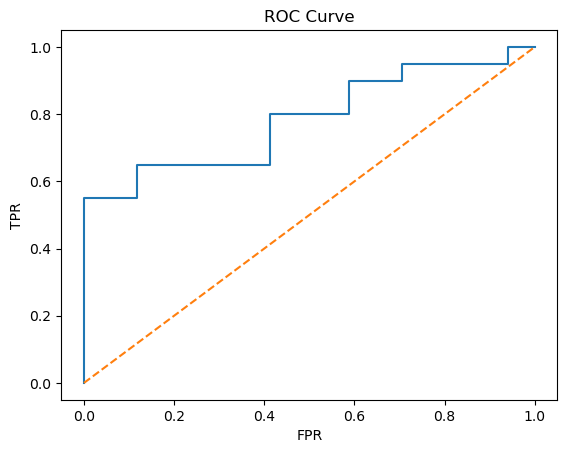

In [26]:
import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.show()

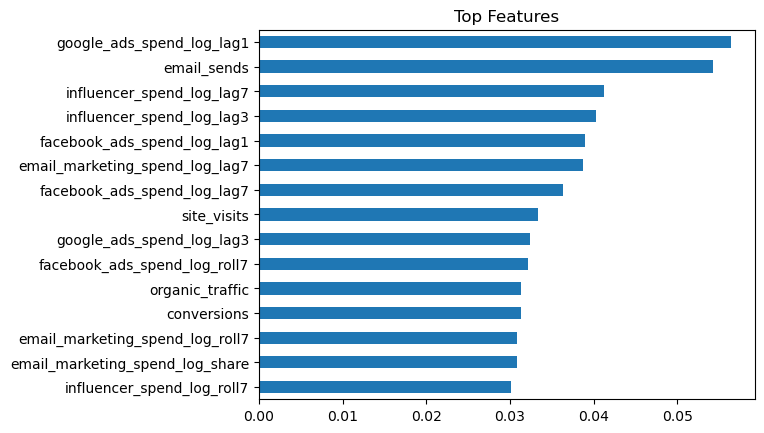

In [27]:
feat_imp.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

Code to prevent data leakage

In [28]:
import numpy as np
import pandas as pd

def prepare_features(df, target_col, allow_revenue_lags=False):
    
    df = df.copy().dropna()
    
    target_cols = ["target_up", "target_big_up", "target_multi"]
    
    y = df[target_col]
    
    X = df.drop(columns=target_cols + ["date"], errors="ignore")
    
    # Remove revenue leakage
    if allow_revenue_lags:
        allowed = ["revenue_lag1", "revenue_lag3", "revenue_lag7"]
        X = X[[c for c in X.columns if ("revenue" not in c) or (c in allowed)]]
    else:
        X = X[[c for c in X.columns if "revenue" not in c]]
    
    X = X.select_dtypes(include=[np.number])
    
    return X, y

In [29]:
def time_split(X, y, split=0.8):
    idx = int(len(X) * split)
    return X.iloc[:idx], X.iloc[idx:], y.iloc[:idx], y.iloc[idx:]

In [30]:
from sklearn.metrics import accuracy_score

def optimize_threshold(y_true, y_prob):
    thresholds = np.linspace(0.1, 0.9, 50)
    
    best_acc = 0
    best_thresh = 0.5
    
    for t in thresholds:
        preds = (y_prob > t).astype(int)
        acc = accuracy_score(y_true, preds)
        
        if acc > best_acc:
            best_acc = acc
            best_thresh = t
    
    return best_thresh, best_acc

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

def tune_random_forest(X_train, y_train, X_test, y_test):
    
    param_grid = {
        "n_estimators": [200, 500],
        "max_depth": [4, 6, 8],
        "min_samples_leaf": [1, 5]
    }
    
    results = []
    
    for n in param_grid["n_estimators"]:
        for d in param_grid["max_depth"]:
            for leaf in param_grid["min_samples_leaf"]:
                
                rf = RandomForestClassifier(
                    n_estimators=n,
                    max_depth=d,
                    min_samples_leaf=leaf,
                    random_state=42,
                    n_jobs=-1
                )
                
                rf.fit(X_train, y_train)
                
                y_prob = rf.predict_proba(X_test)[:, 1]
                
                auc = roc_auc_score(y_test, y_prob)
                thresh, acc = optimize_threshold(y_test, y_prob)
                
                results.append({
                    "model": rf,
                    "auc": auc,
                    "accuracy": acc,
                    "threshold": thresh,
                    "params": (n, d, leaf)
                })
    
    results_df = pd.DataFrame(results)
    
    best_row = results_df.sort_values("auc", ascending=False).iloc[0]
    
    return best_row

In [32]:
def select_top_features(model, X_train, top_n=10):
    importances = pd.Series(model.feature_importances_, index=X_train.columns)
    top_features = importances.sort_values(ascending=False).head(top_n).index.tolist()
    return top_features

In [33]:
def run_full_pipeline(datasets, target_col="target_up"):
    
    final_results = []
    
    for name, df in datasets.items():
        
        print(f"\nRunning dataset: {name}")
        
        # Prepare features
        X, y = prepare_features(df, target_col)
        
        # Split
        X_train, X_test, y_train, y_test = time_split(X, y)
        
        # Tune RF
        best = tune_random_forest(X_train, y_train, X_test, y_test)
        
        model = best["model"]
        
        # Feature selection
        top_features = select_top_features(model, X_train, top_n=10)
        
        # Retrain with top features
        model.fit(X_train[top_features], y_train)
        
        y_prob = model.predict_proba(X_test[top_features])[:, 1]
        
        auc = roc_auc_score(y_test, y_prob)
        thresh, acc = optimize_threshold(y_test, y_prob)
        
        final_results.append({
            "dataset": name,
            "auc": auc,
            "accuracy": acc,
            "threshold": thresh,
            "features": top_features,
            "model": model
        })
    
    results_df = pd.DataFrame(final_results).sort_values("auc", ascending=False)
    
    best_overall = results_df.iloc[0]
    
    return results_df, best_overall

In [34]:
df = pd.read_csv(
    "../data/raw/marketing_roi_dataset.csv",
    parse_dates=["date"]
)

df = df.sort_values("date").reset_index(drop=True)
# Fill missing values (simple + consistent)
for col in df.columns:
    if col != "date":
        df[col] = df[col].fillna(df[col].median())
# Predict whether revenue goes UP tomorrow
df["revenue_diff"] = df["revenue"].diff()
df["target_up"] = (df["revenue_diff"] > 0).astype(int)

df = df.dropna().reset_index(drop=True)
df_raw = df.copy()

In [35]:
lag_cols = [
    "google_ads_spend",
    "facebook_ads_spend",
    "email_marketing_spend",
    "influencer_spend",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions",
    "revenue"
]

df_lag = df.copy()

for col in lag_cols:
    for lag in [1, 2, 3, 4, 5, 6, 7]:
        df_lag[f"{col}_lag{lag}"] = df_lag[col].shift(lag)

df_lag = df_lag.dropna().reset_index(drop=True)

In [36]:
df_roll = df.copy()

for col in lag_cols:
    df_roll[f"{col}_roll7"] = df_roll[col].rolling(7).mean()

df_roll = df_roll.dropna().reset_index(drop=True)

In [37]:
df_diff = df.copy()

for col in lag_cols:
    df_diff[f"{col}_diff"] = df_diff[col].diff()

df_diff = df_diff.dropna().reset_index(drop=True)

In [38]:
df_narrow = df[[
    "google_ads_spend",
    "facebook_ads_spend",
    "email_sends",
    "conversions",
    "target_up"
]].copy()

In [39]:
datasets = {
    "raw": df_raw,
    "lag": df_lag,
    "diff": df_diff,
    "rolling": df_roll,
    "narrow": df_narrow
}

results_df, best_model_info = run_full_pipeline(datasets, target_col="target_up")

print(results_df[["dataset", "auc", "accuracy", "threshold"]])


Running dataset: raw

Running dataset: lag

Running dataset: diff

Running dataset: rolling

Running dataset: narrow
   dataset       auc  accuracy  threshold
2     diff  0.624362  0.610000   0.442857
1      lag  0.604971  0.608040   0.475510
0      raw  0.563156  0.560000   0.459184
3  rolling  0.553748  0.552764   0.475510
4   narrow  0.519552  0.560000   0.475510
